# Load packages

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats



# Cell type heatmap

In [2]:
data_raw = pd.read_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Data_AllMarkers_filtered_2.csv')

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_11016/1233858107.py:1: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Data_AllMarkers_filtered_2.csv')


## Two separate plots

In [5]:
# --- Data Preparation Setup ---
# 1. Create a copy to avoid mutating raw data
data_processed = data_raw.copy()

# 2. Map the 4 specific tumor subtypes to a single 'Tumor' category for the main plot
tumor_mapping = {
    'Tumor.GCLC+VIM+': 'Tumor',
    'Tumor.GCLC+VIM-': 'Tumor',
    'Tumor.GCLC-VIM+': 'Tumor',
    'Tumor.GCLC-VIM-': 'Tumor'
}

lineage_markers = ['panCK', 'E.Cadherin', 'CD68', 'CD206', 'CD45', 'CD8a', 'CD4', 'FOXP3', 'SMA','Vimentin']
groupby_column = 'GCLC_VIM' 

# Replace the tumor subtypes in your grouping column to create the general 'Tumor' label
data_processed['General_Cell_Type'] = data_processed[groupby_column].replace(tumor_mapping)

# 3. Calculate means for both scenarios
main_heatmap_data = data_processed.groupby('General_Cell_Type')[lineage_markers].mean()
subtype_heatmap_data = data_raw.groupby(groupby_column)[lineage_markers].mean()


# --- Shared Plotting Configurations ---
ordered_markers = [
    'CD45', 'CD8a', 'CD4', 'FOXP3',                # Immune markers
    'CD68', 'CD206',                               # Macrophage markers
    'SMA',                                         # Stroma markers
    'panCK', 'E.Cadherin', 'Vimentin'              # Tumor markers
]

colors = [
    (0.0, "#1f65b4"),
    (0.48, "#adcbe3"),
    (0.50, "#ffffff"),
    (0.52, "#f8b4a2"),
    (1.0, "#b2182b")
]
custom_cmap = mcolors.LinearSegmentedColormap.from_list("sharp_split", colors)

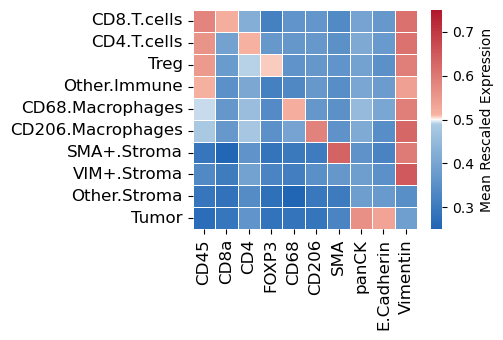

In [7]:
# Define main cell types (Notice 'Tumor' replaces the 4 specific subtypes)
ordered_main_cells = [
    'CD8.T.cells', 'CD4.T.cells', 'Treg', 'Other.Immune',
    'CD68.Macrophages', 'CD206.Macrophages',
    'SMA+.Stroma', 'VIM+.Stroma', 'Other.Stroma',
    'Tumor' 
]

plot_data_main = main_heatmap_data.loc[ordered_main_cells, ordered_markers]

plt.figure(figsize=(5, 3.5)) # Slightly reduced height since there are fewer rows
sns.heatmap(plot_data_main, 
            cmap=custom_cmap, 
            vmin=0.25,      
            vmax=0.75,      
            center=0.50,    
            annot=False, 
            linewidths=.4, 
            cbar_kws={'label': 'Mean Rescaled Expression'})

plt.xlabel('', fontsize=12)
plt.ylabel('', fontsize=12)
plt.xticks(rotation=90, ha='center', va='top', fontsize=12) 
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/new_plots/main_cell_types_heatmap.pdf', dpi=300)
plt.show()

# Violin plot

In [15]:
data_raw.columns

Index(['CellID', 'S9.6', 'HER3', 'panCK', 'SMA', 'CD45', 'Ki67_2', 'CD4',
       'FOXP3', 'CD8a', 'CD11b', 'CD68', 'CD206', 'H2ax', 'Vimentin',
       'H3K27me3', 'E.Cadherin', 'GCLC', 'TXNRD1', 'NQO1', 'pERK', 'TXN',
       'pSTAT3', 'pS6_235', 'pRB', 'GLUT1', 'X_centroid', 'Y_centroid',
       'imageid', 'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage',
       'patient_id_AB19_1654', 'Area', 'Eccentricity', 'antioxidant_NQOI',
       'antioxidant_GCLC', 'antioxidant_TXNRD1', 'antioxidant_GLUT1',
       'NQO1_GCLC_VIM', 'celltype_2', 'celltype_1', 'Tumor_state', 'GCLC_VIM',
       'CellCategory'],
      dtype='object')

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_11016/1627538140.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_11016/1627538140.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_11016/1627538140.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


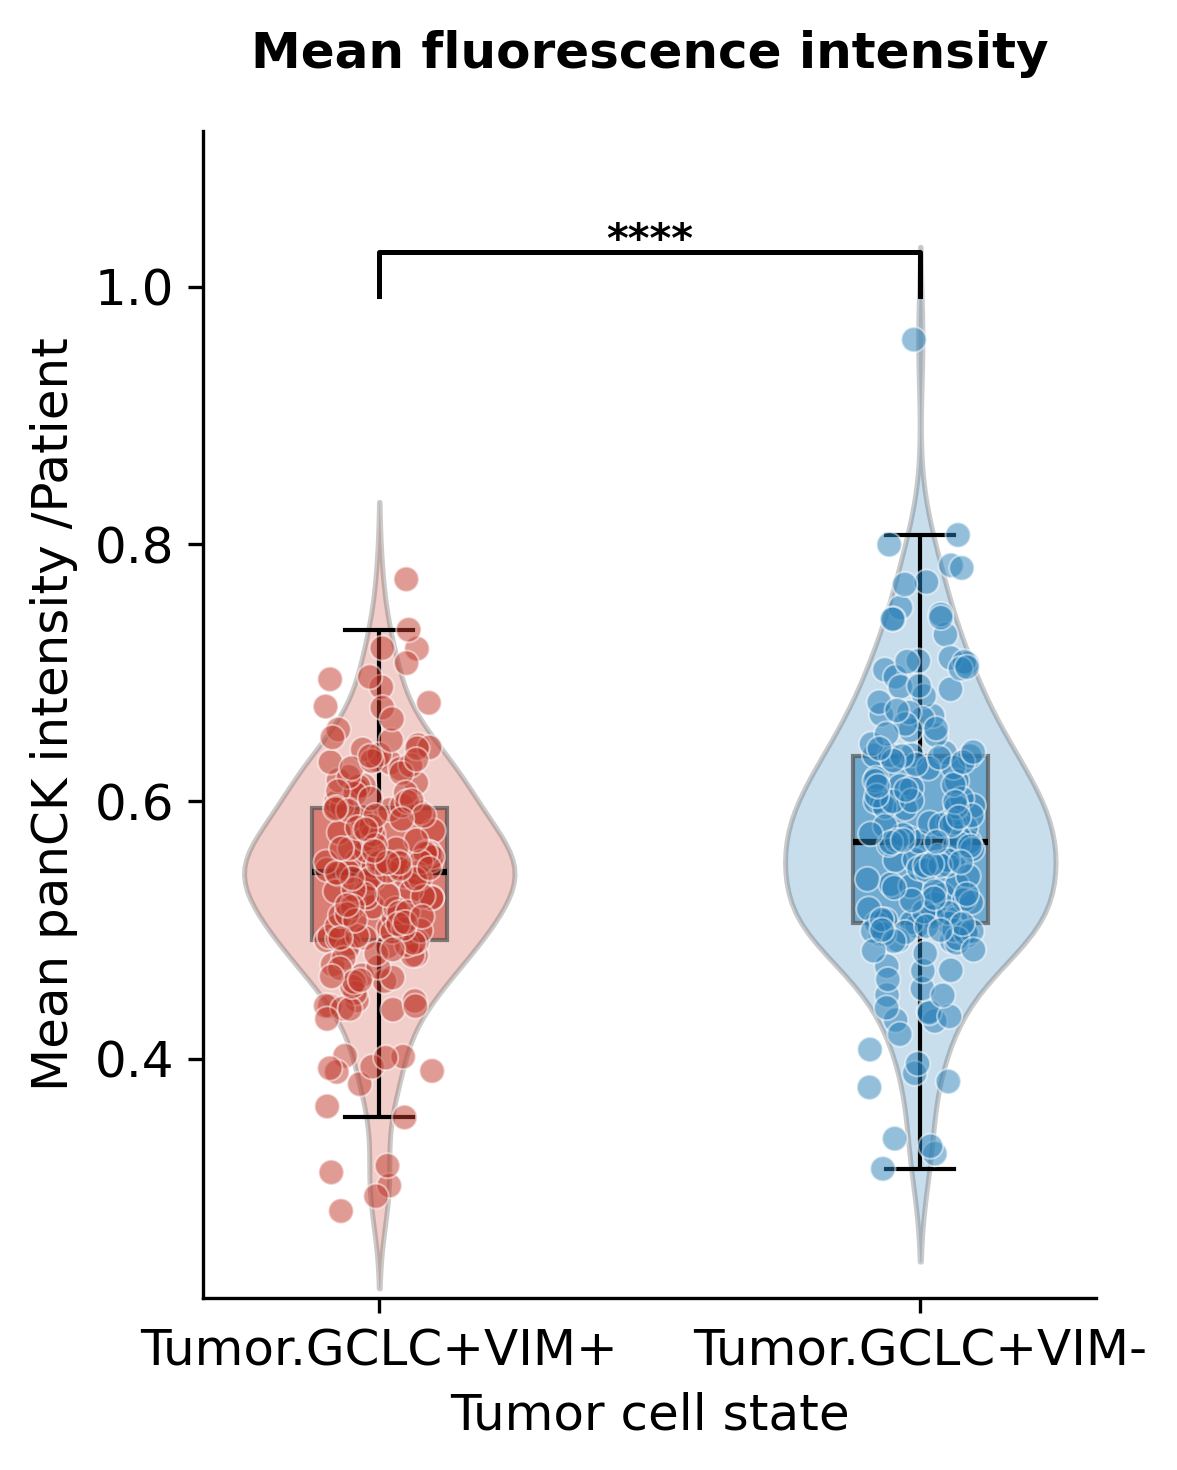

In [40]:
# set the column names for clarity
sample_column = "patient_id_AB19_1654"
groupby_column = "GCLC_VIM"
target_subtypes = ["Tumor.GCLC+VIM+", "Tumor.GCLC+VIM-"]

# calculate the mean panCK intensity for each patient and each tumor subtype
filtered_data = data_raw[data_raw[groupby_column].isin(target_subtypes)].copy()
patient_means = (
    filtered_data.groupby([sample_column, groupby_column])["panCK"]
    .mean()
    .reset_index()
)

# create a pivot table to get paired data for statistical testing
paired_df = patient_means.pivot(
    index=sample_column, columns=groupby_column, values="panCK"
).dropna()
stat, p_val = stats.white_rank_or_wilcoxon = stats.wilcoxon(
    paired_df[target_subtypes[0]], paired_df[target_subtypes[1]]
)

# plotting
plt.figure(figsize=(4, 5), dpi=300)
palette_colors = ["#e74c3c", "#3498db"] 

# violin plot
sns.violinplot(
    data=patient_means,
    x=groupby_column,
    y="panCK",
    order=target_subtypes,
    palette=palette_colors,
    inner=None,
    alpha=0.3,
    linewidth=1.2,
    width=0.5
)

# boxplot
sns.boxplot(
    data=patient_means,
    x=groupby_column,
    y="panCK",
    order=target_subtypes,
    width=0.25,
    palette=palette_colors,
    showfliers=False,
    boxprops=dict(alpha=0.7),  
    capprops=dict(color="black"),
    whiskerprops=dict(color="black"),
    medianprops=dict(color="black", linewidth=1.5), 
)

# dot plot
sns.stripplot(
    data=patient_means,
    x=groupby_column,
    y="panCK",
    order=target_subtypes,
    palette=["#c0392b", "#2980b9"], 
    size=6,  
    jitter=0.1, 
    alpha=0.5,
    edgecolor="white",
    linewidth=0.5,
)

# add statistical annotation
y_max = patient_means["panCK"].max()
y_min = patient_means["panCK"].min()
h = (y_max - y_min) * 0.05
line_y = y_max + h
text_y = line_y + h * 0.8

plt.plot([0, 0, 1, 1], [line_y, line_y + h, line_y + h, line_y], lw=1.2, c="black")

if p_val < 0.0001:
    p_text = f"****"
elif p_val < 0.001:
    p_text = f"***"
elif p_val < 0.01:
    p_text = f"**"
elif p_val < 0.05:
    p_text = f"*"
else:
    p_text = f"ns"

plt.text(0.5, text_y, f"{p_text}", ha="center",
            va="bottom", fontsize=10, fontweight="semibold",)
plt.ylim(y_min - h * 2, text_y + h * 3)

plt.title(
    f"Mean fluorescence intensity",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Tumor cell state", fontsize=12)
plt.ylabel("Mean panCK intensity /Patient", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

sns.despine()
plt.tight_layout()
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/new_plots/panCK_Violin.pdf', dpi=300)
plt.show()